In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
train_df = pd.read_csv("/content/DailyDelhiClimateTrain.csv")
test_df = pd.read_csv("/content/DailyDelhiClimateTest.csv")

train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
print(train_df.shape,
test_df.shape)

(1462, 5) (114, 5)


## **Data Exploration (EDA)**

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [7]:
train_df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


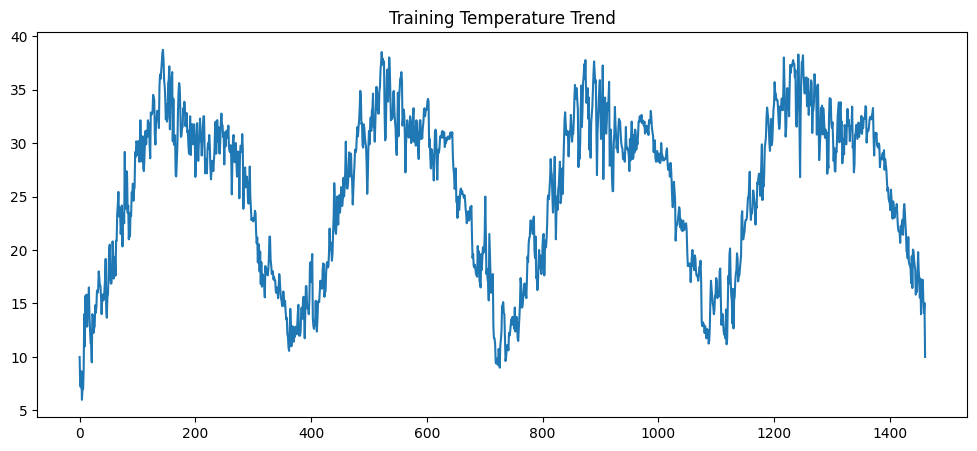

In [20]:
plt.figure(figsize=(12,5))
plt.plot(train_df['meantemp'])
plt.title("Training Temperature Trend")
plt.show()

In [9]:
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

In [11]:
train_data = train_df[['meantemp']]
test_data = test_df[['meantemp']]

In [12]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)

test_scaled = scaler.transform(test_data)

In [13]:
sequence_length = 30

X_train = []
y_train = []

for i in range(sequence_length, len(train_scaled)):

    X_train.append(train_scaled[i-sequence_length:i])

    y_train.append(train_scaled[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [14]:
X_test = []
y_test = []

for i in range(sequence_length, len(test_scaled)):

    X_test.append(test_scaled[i-sequence_length:i])

    y_test.append(test_scaled[i])

X_test = np.array(X_test)
y_test = np.array(y_test)

In [15]:
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.models import Sequential

In [16]:
model = Sequential()

model.add(SimpleRNN(
    units=50,
    return_sequences=True,
    input_shape=(30,1)
))

model.add(SimpleRNN(50))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1298 - val_loss: 0.0059
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0044 - val_loss: 0.0072
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0042 - val_loss: 0.0056
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0039 - val_loss: 0.0041
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0042 - val_loss: 0.0044
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029 - val_loss: 0.0030
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0031 - val_loss: 0.0051
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029 - val_loss: 0.0042
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0

In [18]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step


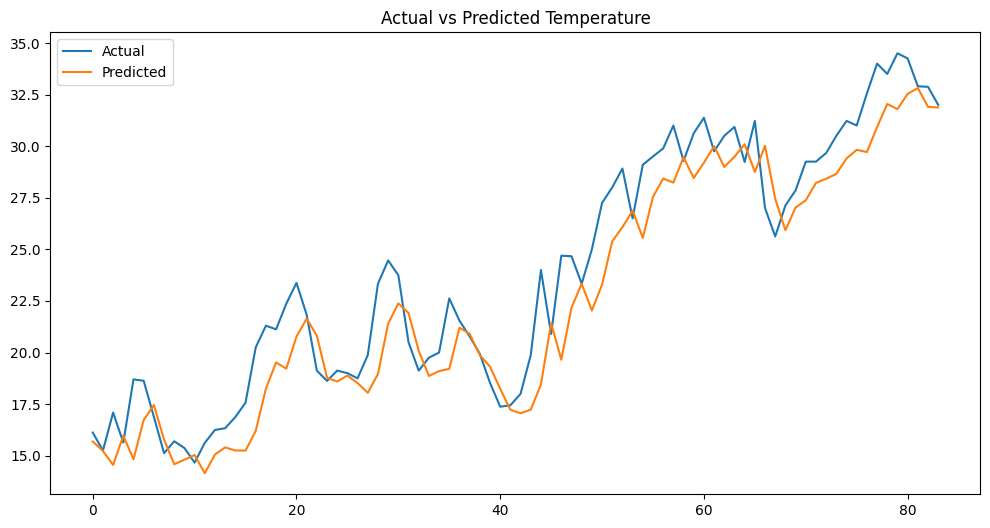

In [19]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual")

plt.plot(predictions, label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Temperature")

plt.show()